In [ ]:
import qiskit


---
#  Noise Models: Simulating Reality

## 1. Theory: Why is the Real World "Noisy"?

So far, we have been using an **"Ideal Simulator."**

* If we apply an X-gate, it flips the qubit 100% of the time.
* If we leave a qubit alone, it stays in its state forever.

**The Reality:** Real quantum computers are fragile. They suffer from **Noise**.
Noise is any unwanted interaction with the environment that messes up our information.

### Common Types of Quantum Noise:

1. **Bit Flip Error:** You wanted the qubit to stay , but it accidentally flipped to .
2. **Phase Flip Error:** The qubit stayed , but its phase changed (like an accidental Z-gate).
3. **Depolarizing Error:** The qubit completely loses its information and becomes random garbage.
4. **Readout Error:** The qubit was correctly , but the measurement device made a mistake and reported '1'.

**What is a Noise Model?**
A **Noise Model** is a Python object in Qiskit `Aer` that lets us mathematicaly define these errors. We can say: *"Hey Simulator, act like a real machine where there is a 5% chance of a Bit Flip every time I use an X-gate."*

---

## 2. Code: creating a "Noisy" Simulation

In this code, we will intentionally break our perfect simulation by adding a **Bit Flip Error**.

**The Scenario:**
We will run a circuit that does... absolutely nothing (Identity). Ideally, the output should be 100% `0`. But with noise, we will see some `1`s appear.





Noisy Results: {'0': 826, '1': 174}


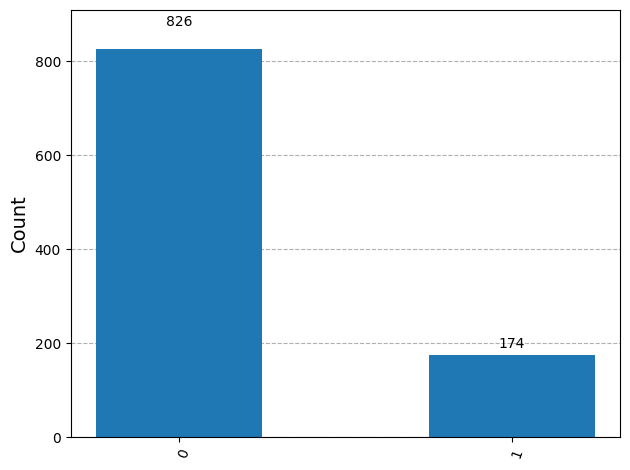

In [2]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, pauli_error
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# --- Step 1: Define the Error ---
# We create a "Bit Flip" error (X-gate error)
# probability = 0.2 means there is a 20% chance of an error occurring.
error_prob = 0.2
bit_flip = pauli_error([('X', error_prob), ('I', 1 - error_prob)])

# --- Step 2: Create a Noise Model ---
noise_model = NoiseModel()

# We tell the model: "Add this bit_flip error to ALL 'id' (identity/wait) gates on qubit 0"
noise_model.add_quantum_error(bit_flip, ['id'], [0])

# --- Step 3: Build the Circuit ---
qc = QuantumCircuit(1, 1)
qc.id(0) # Do nothing (This should trigger the error!)
qc.measure(0, 0)

# --- Step 4: Run the Simulation with Noise ---
# We pass the noise_model to the simulator
sim_noise = AerSimulator(noise_model=noise_model)

# Run standard simulation
result = sim_noise.run(qc, shots=1000).result()
counts = result.get_counts()

print("Noisy Results:", counts)
# Ideally, we should see 100% '0'.
# But you will see roughly 800 '0's and 200 '1's (due to the 20% noise).
display(plot_histogram(counts))
plt.show()


## 3. Exercises

### Exercise 1: The Noisy Bell State

**Goal:** See how noise destroys entanglement.

* **Task:**
1. Create a standard Bell State circuit ().
2. Create a `NoiseModel` with a **10% Depolarizing Error** (`depolarizing_error`) on the CNOT gate.
3. Run the simulation.


* **Observation:** Ideally, a Bell state is 50% `00` and 50% `11`. With noise, you will start seeing "impossible" results like `01` and `10` appearing in the histogram. This is exactly what happens on real IBM hardware!

### Exercise 2: Comparing Ideal vs. Noisy

**Goal:** Run the same circuit twice to see the difference side-by-side.

* **Task:**
1. Define a circuit with 5 X-gates in a row: `qc.x(0)` repeated 5 times. (Since 5 is odd, the result should be ).
2. Run it on a standard `AerSimulator()` (Ideal).
3. Run it on a `AerSimulator(noise_model=my_noise)` (Noisy).
4. Compare the histograms.

